# Feature Effect Performance Regimes
This notebook assembles a run-scoped regime analysis table for one interpretable-model run, evaluates reduced feature-effect representations, compares clustering behavior across performance groups, and exports lean per-candidate cluster artifacts for downstream inspection. Cluster inspection happens in `feature_effect_pr_cluster_inspection.ipynb`.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.prepared_data import load_prepared_data, prepare_single_target_model_data
from data_modelling.run_context import format_exported_model_label, get_exported_model_info, load_run_context
from data_modelling.feature_effect_cluster_exports import write_cluster_exports
from data_modelling.feature_effect_performance_regimes_utils import (
    TRUSTWORTHINESS_COLUMNS,
    assemble_step1_analysis_table,
    assert_columns_present,
    build_feature_effect_regime_artifact_names,
    build_feature_effect_regime_export_layout,
    evaluate_umap_trustworthiness_by_group,
    get_effect_cols,
    load_or_initialize_feature_effect_regime_manifest,
    merge_feature_effect_regime_artifact_records,
    resolve_cluster_spec,
    resolve_feature_effect_regime_export_context,
    resolve_raw_metric_col,
    run_step2_clustering,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam'
RUN_NAME = 'nusc_trainval_debug_tpp-12_Apr_2026_22_51_36'
EVAL_CSV_NAME = 'eval_epoch_5.csv'
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True
PERFORMANCE_GROUP_COL = 'performance_group'

CLUSTER_SPEC = {
    'groups': ['easy', 'medium', 'hard'],
    'algorithms': ['hdbscan', 'optics'],
    'evaluate_umap_latent_space': True,
    # Set one integer for all groups or a dict like {'easy': 2, 'medium': 4, 'hard': 2}.
    'umap_selected_n_components': {'easy': 3, 'medium': 3, 'hard': 3},
    'trustworthiness_neighbor_values': [5, 10, 15],
    'cluster_umap_n_neighbors': 30,
    'cluster_umap_min_dist': 0.0,
    'viz_umap_n_neighbors': 15,
    'viz_umap_min_dist': 0.1,
    'random_state': 42,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_cluster_size': 5,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_samples': 5,
    'optics_cluster_method': 'xi',
    'optics_xi': 0.05,
    'distance_metric': 'euclidean',
}


## Resolve Run Context and Artifact Paths
**Purpose:** Tie every input and output to one exported modelling run and one joined-metrics file.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, `EVAL_CSV_NAME`, optional `TARGET_COL`.<br>
**Outputs:** Resolved run metadata, source artifact paths, and result directories for this notebook run.<br>
**How to Verify:** Confirm the printed target, feature count, model label, and source paths match the exported run you intend to analyze.


In [2]:
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = run_ctx.manifest
target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
exported_model_info = get_exported_model_info(manifest)
exported_model_label = format_exported_model_label(exported_model_info)
target_mode = exported_model_info['target_mode']
raw_metric_col = resolve_raw_metric_col(manifest, target_col)

PREPARED_DATA_PATH = Path('../../results/interpretable_model/prepared_data') / RUN_NAME / f'prepared_data_{raw_metric_col}.csv'
FEATURE_EFFECTS_PATH = run_ctx.tables_dir / f'feature_effects_{target_col}.csv'
FEATURE_EFFECT_IMPORTANCE_PATH = run_ctx.tables_dir / f'feature_effect_importance_{target_col}.csv'
JOINED_METRICS_PATH = Path('../../results/trajectory_prediction/trajectory_metrics_joined') / RUN_NAME / EVAL_CSV_NAME
FEATURE_EFFECT_REGIME_RESULTS_ROOT = Path('../../results/interpretable_model/feature_effect_performance_regimes')

required_paths = [
    ('prepared data export', PREPARED_DATA_PATH),
    ('feature-effect export', FEATURE_EFFECTS_PATH),
    ('feature-effect importance export', FEATURE_EFFECT_IMPORTANCE_PATH),
    ('joined metrics export', JOINED_METRICS_PATH),
]
for label, path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f'Missing required {label}: {path}')

print(f'Run: {RUN_NAME}')
print(f'Eval CSV: {EVAL_CSV_NAME}')
print(f'Exported model: {exported_model_label}')
print(f'Model ID: {MODEL_ID} | target_mode: {target_mode}')
print(f'Resolved target_col: {target_col}')
print(f'Resolved raw_metric_col: {raw_metric_col}')
print(f'Feature count: {len(feature_cols)}')
print(f'Prepared data path: {PREPARED_DATA_PATH}')
print(f'Feature-effect path: {FEATURE_EFFECTS_PATH}')
print(f'Feature-effect ranking path: {FEATURE_EFFECT_IMPORTANCE_PATH}')
print(f'Joined metrics path: {JOINED_METRICS_PATH}')
print(f'Feature-effect regime export root: {FEATURE_EFFECT_REGIME_RESULTS_ROOT.resolve()}')


Run: nusc_trainval_debug_tpp-12_Apr_2026_22_51_36
Eval CSV: eval_epoch_5.csv
Exported model: LinearGAM (no log) (linear, target_mode=raw)
Model ID: gam | target_mode: raw
Resolved target_col: ml_ade_log
Resolved raw_metric_col: ml_ade
Feature count: 13
Prepared data path: ../../results/interpretable_model/prepared_data/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/prepared_data_ml_ade.csv
Feature-effect path: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/tables/feature_effects_ml_ade_log.csv
Feature-effect ranking path: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/tables/feature_effect_importance_ml_ade_log.csv
Joined metrics path: ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/eval_epoch_5.csv
Feature-effect regime export root: /Users/simondrauz

## Load the Prepared Modelling Table
**Purpose:** Reconstruct the exact modelling rows and feature key used by the interpretable model.<br>
**Inputs:** `PREPARED_DATA_PATH`, resolved `target_col`, resolved `raw_metric_col`, and manifest `feature_cols`.<br>
**Outputs:** `model_df` on the notebook's modelling rows plus a verified feature-key definition.<br>
**How to Verify:** Check that the prepared target and feature columns exactly match the run manifest and that the printed row count looks plausible.


In [3]:
prepared_df = load_prepared_data(
    PREPARED_DATA_PATH,
    display_fn=display,
    include_missing_summary=True,
    include_dtype_summary=True,
)

prepared = prepare_single_target_model_data(
    prepared_df,
    target_col=target_col,
    default_target=raw_metric_col,
)
model_df = prepared['model_df'].copy()
prepared_feature_cols = prepared['feature_cols']

if prepared['target_col'] != target_col:
    raise ValueError(f"Prepared target mismatch. expected={target_col}, actual={prepared['target_col']}")
if prepared_feature_cols != feature_cols:
    raise ValueError(
        'Prepared feature columns do not match the run manifest exactly. '
        f'expected={feature_cols}, actual={prepared_feature_cols}'
    )

print(f'Prepared modelling rows: {len(model_df)}')
print(f'Prepared feature key size: {len(prepared_feature_cols)}')


Dataset shape: (26122, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'path_efficiency', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_num_VEHICLE', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,path_efficiency,has_collision,min_neighbor_distance,scene_num_agents,scene_num_VEHICLE,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.188157,0.010906,0.001433,99.888973,0.0,4.615938,20.0,7.0,1011.997836,41.958336,24.119113,0.019763,0.006917,0.245121
1,0.062610,0.016326,-0.002263,76.416329,0.0,2.246425,24.0,4.0,967.632298,29.085719,33.268296,0.024803,0.004134,0.112933
2,0.070114,0.020558,-0.001067,13.848970,0.0,14.166255,18.0,13.0,1152.139136,36.252304,31.781128,0.015623,0.011283,0.024980
3,1.764128,0.182014,0.049439,99.605300,0.0,1.674341,29.0,13.0,911.855176,43.725631,20.854020,0.031803,0.014257,0.205893
4,1.829165,0.082353,-0.007304,98.503726,0.0,1.153281,13.0,5.0,968.347670,31.758533,30.490944,0.013425,0.005163,0.286451



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
path_efficiency,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_num_VEHICLE,0
scene_bbox_area,0
scene_bbox_width,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
path_efficiency,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_num_VEHICLE,float64
scene_bbox_area,float64
scene_bbox_width,float64


Prepared modelling rows: 26122
Prepared feature key size: 13


## Assemble the Performance-Regime Table
**Purpose:** Join prepared rows, run-scoped metrics, and feature-effect exports, then validate the clustering configuration against the loaded feature-effect columns.<br>
**Inputs:** `model_df`, `JOINED_METRICS_PATH`, `FEATURE_EFFECTS_PATH`, `FEATURE_EFFECT_IMPORTANCE_PATH`, and `CLUSTER_SPEC`.<br>
**Outputs:** `analysis_df`, performance-group summaries, ordered global ranking metadata, resolved clustering config, and the export paths used by the notebook.<br>
**How to Verify:** Confirm the join row counts, the detected feature-effect count, and the resolved UMAP candidate dimensions before moving to reduced-space evaluation.


In [4]:
def build_trustworthiness_plot_titles(cluster_spec: dict[str, object]) -> dict[str, str]:
    plot_titles = {
        f'nn_{neighbor_value}': (
            'UMAP trustworthiness by reduced dimension and performance group ' f'(n_neighbors={neighbor_value})'
        )
        for neighbor_value in cluster_spec['trustworthiness_neighbor_values']
    }
    neighbor_label = ', '.join(str(value) for value in cluster_spec['trustworthiness_neighbor_values'])
    plot_titles[cluster_spec['trustworthiness_mean_view']] = (
        'UMAP trustworthiness by reduced dimension and performance group ' f'(mean over n_neighbors={neighbor_label})'
    )
    return plot_titles

joined_metrics_df = pd.read_csv(JOINED_METRICS_PATH)
feature_effects_df = pd.read_csv(FEATURE_EFFECTS_PATH)
feature_effect_ranking_df = pd.read_csv(FEATURE_EFFECT_IMPORTANCE_PATH)
assert_columns_present(
    feature_effect_ranking_df,
    ['feature', 'global_rank', 'importance_metric', 'importance_value', 'importance_ascending'],
    df_name='feature-effect ranking export',
)
feature_effect_ranking_df = feature_effect_ranking_df.sort_values(['global_rank', 'feature']).reset_index(drop=True)

analysis_df, group_summary_df = assemble_step1_analysis_table(
    prepared_model_df=model_df,
    joined_metrics_df=joined_metrics_df,
    feature_effects_df=feature_effects_df,
    feature_cols=feature_cols,
    target_col=target_col,
    performance_metric_col=raw_metric_col,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
)

effect_cols = get_effect_cols(analysis_df)
CLUSTER_SPEC_RESOLVED = resolve_cluster_spec(CLUSTER_SPEC, effect_cols=effect_cols)
EXPORT_CONTEXT = resolve_feature_effect_regime_export_context(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    eval_csv_name=EVAL_CSV_NAME,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
    results_root=FEATURE_EFFECT_REGIME_RESULTS_ROOT,
)
EXPORT_LAYOUT = build_feature_effect_regime_export_layout(
    export_context=EXPORT_CONTEXT,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
)
ARTIFACT_NAMES = build_feature_effect_regime_artifact_names(cluster_spec=CLUSTER_SPEC_RESOLVED)
TABLES_DIR = EXPORT_LAYOUT['tables_dir']
PLOTS_DIR = EXPORT_LAYOUT['plots_dir']
EXPORT_MANIFEST_PATH = EXPORT_LAYOUT['manifest_path']

REGIME_ANALYSIS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['regime_analysis']
PERFORMANCE_GROUP_SUMMARY_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['performance_group_summary']
UMAP_TRUSTWORTHINESS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['umap_trustworthiness']
CLUSTER_SCORES_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_scores']
CLUSTER_ASSIGNMENTS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_assignments']
CLUSTER_FEATURE_EFFECT_PROFILES_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_feature_effect_profiles']
CLUSTER_CATALOG_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_catalog']
FEATURE_EFFECT_GLOBAL_RANKING_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['feature_effect_global_ranking']
RAW_ALGORITHM_GRID_PATH = PLOTS_DIR / ARTIFACT_NAMES['plots']['raw_algorithm_comparison_grid']
UMAP_ALGORITHM_GRID_PATH = PLOTS_DIR / ARTIFACT_NAMES['plots']['umap_algorithm_comparison_grid']

if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {
        trustworthiness_view: PLOTS_DIR / plot_name
        for trustworthiness_view, plot_name in ARTIFACT_NAMES['plots']['umap_trustworthiness_curves'].items()
    }
    TRUSTWORTHINESS_PLOT_TITLES = build_trustworthiness_plot_titles(CLUSTER_SPEC_RESOLVED)
else:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {}
    TRUSTWORTHINESS_PLOT_TITLES = {}

group_counts_df = (
    analysis_df[PERFORMANCE_GROUP_COL].value_counts().rename_axis(PERFORMANCE_GROUP_COL).reset_index(name='count')
)

print(f'Joined metrics rows: {len(joined_metrics_df)}')
print(f'Feature-effect rows: {len(feature_effects_df)}')
print(f'Feature ranking rows: {len(feature_effect_ranking_df)}')
print(f'Analysis rows: {len(analysis_df)}')
print(f'Feature-effect columns available: {len(effect_cols)}')
print(f"Resolved UMAP candidate dimensions: {CLUSTER_SPEC_RESOLVED['umap_candidate_dims']}")
print(f"Cluster-spec export root: {EXPORT_LAYOUT['cluster_spec_root']}")
print(f"Export manifest path (manifest.json): {EXPORT_MANIFEST_PATH}")
display(group_summary_df)
display(group_counts_df)
display(feature_effect_ranking_df.head())
display(analysis_df.head())


Joined metrics rows: 26886
Feature-effect rows: 26122
Feature ranking rows: 13
Analysis rows: 26122
Feature-effect columns available: 13
Resolved UMAP candidate dimensions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Cluster-spec export root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137
Export manifest path (manifest.json): /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/feature_effect_performance_regimes/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__uma

,metric_col,q25,q75,n_total,n_easy,n_medium,n_hard,n_equal_q25,n_equal_q75
0,ml_ade,0.145791,0.679768,26122,6531,13060,6531,0,0


,performance_group,count
0,medium,13060
1,easy,6531
2,hard,6531


,feature,global_rank,p_value,neg_log10_p_value,significant_0_05,importance_metric,importance_value,importance_ascending
0,max_speed,1,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
1,mean_acceleration,2,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
2,path_efficiency,3,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
3,std_speed,4,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
4,min_neighbor_distance,5,1.276868e-12,11.893854,True,p_value,1.276868e-12,True


,row_id,max_speed,std_speed,mean_acceleration,path_efficiency,has_collision,min_neighbor_distance,scene_num_agents,scene_num_VEHICLE,scene_bbox_area,...,effect__min_neighbor_distance,effect__scene_num_agents,effect__scene_num_VEHICLE,effect__scene_bbox_area,effect__scene_bbox_width,effect__scene_bbox_height,effect__scene_spatial_density,effect__scene_density_VEHICLE,effect_base_value,performance_group
0,0,1.188157,0.010906,0.001433,99.888973,0.0,4.615938,20.0,7.0,1011.997836,...,0.065406,0.095124,0.034299,0.012872,-0.031807,-0.011157,-0.595716,0.677160,1.242092,medium
1,1,0.062610,0.016326,-0.002263,76.416329,0.0,2.246425,24.0,4.0,967.632298,...,0.092846,0.102651,0.017953,0.005070,-0.001055,-0.057981,-0.582899,0.683659,1.242092,medium
2,2,0.070114,0.020558,-0.001067,13.848970,0.0,14.166255,18.0,13.0,1152.139136,...,0.071587,0.104306,0.100574,0.013165,-0.004654,-0.052698,-0.607281,0.666909,1.242092,medium
3,3,1.764128,0.182014,0.049439,99.605300,0.0,1.674341,29.0,13.0,911.855176,...,0.059914,0.043189,0.100574,-0.000441,-0.039167,-0.028233,-0.567326,0.659903,1.242092,medium
4,4,1.829165,0.082353,-0.007304,98.503726,0.0,1.153281,13.0,5.0,968.347670,...,0.016797,0.106602,0.040174,0.005186,0.019587,-0.046312,-0.613811,0.681259,1.242092,medium


## Evaluate Reduced Representations
**Purpose:** Compute trustworthiness scores for dimensions `1, 2, ..., (#features - 1)` for each performance group and highlight the configured reduced dimension used for clustering.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `effect_cols`.<br>
**Outputs:** `trustworthiness_df` and one trustworthiness curve per configured neighborhood view when reduced-space evaluation is enabled.<br>
**How to Verify:** Check that every performance group appears in the trustworthiness curves and that the highlighted points match `CLUSTER_SPEC['umap_selected_n_components']`.


/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

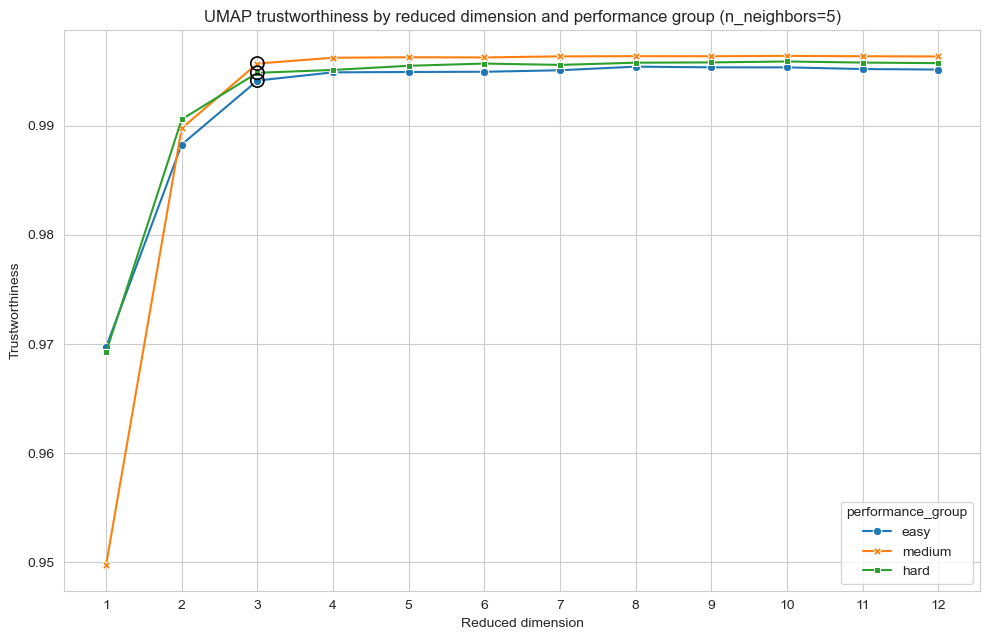

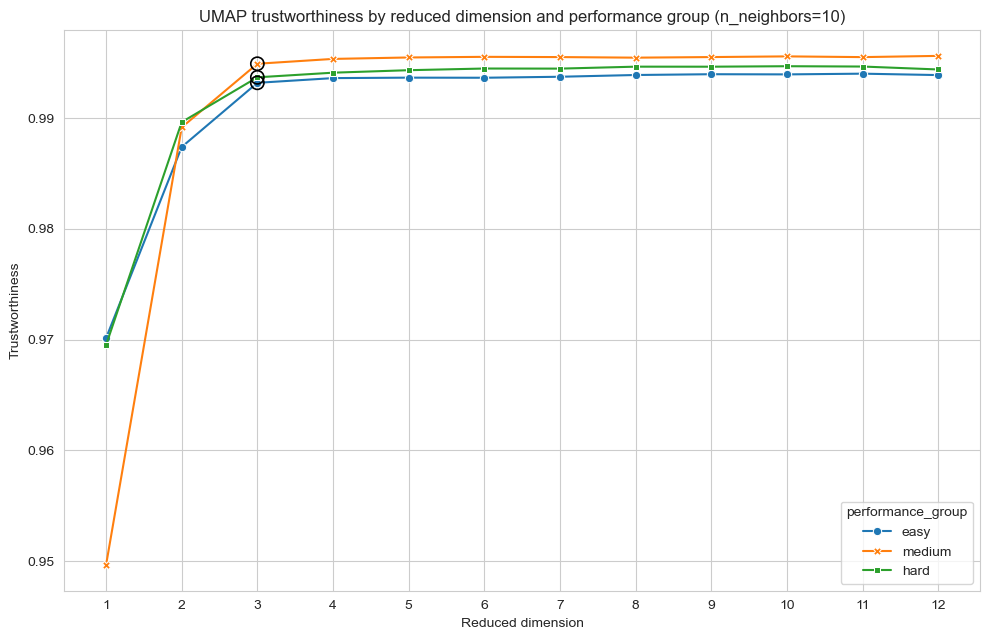

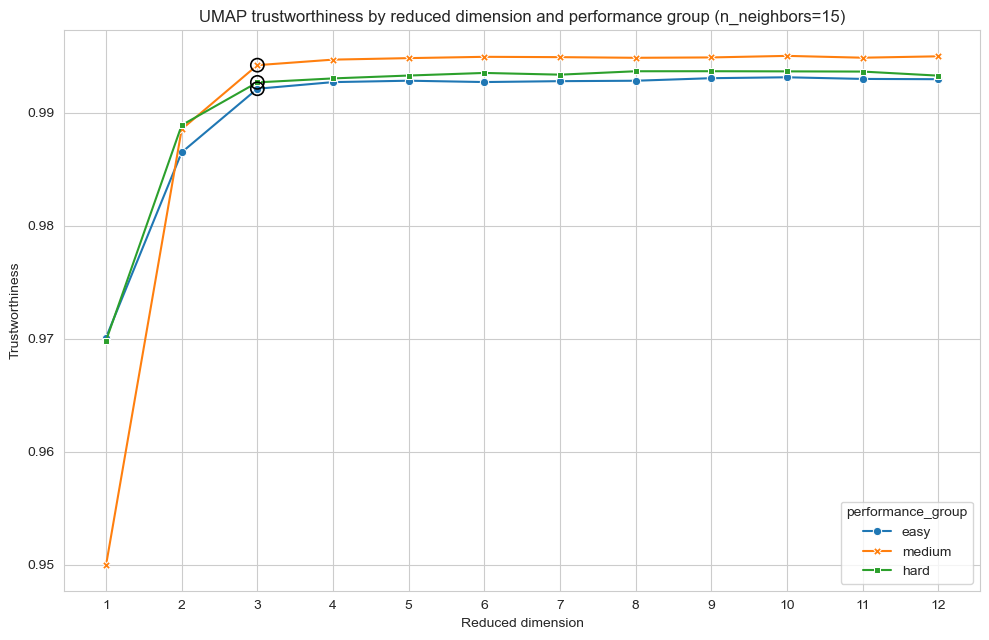

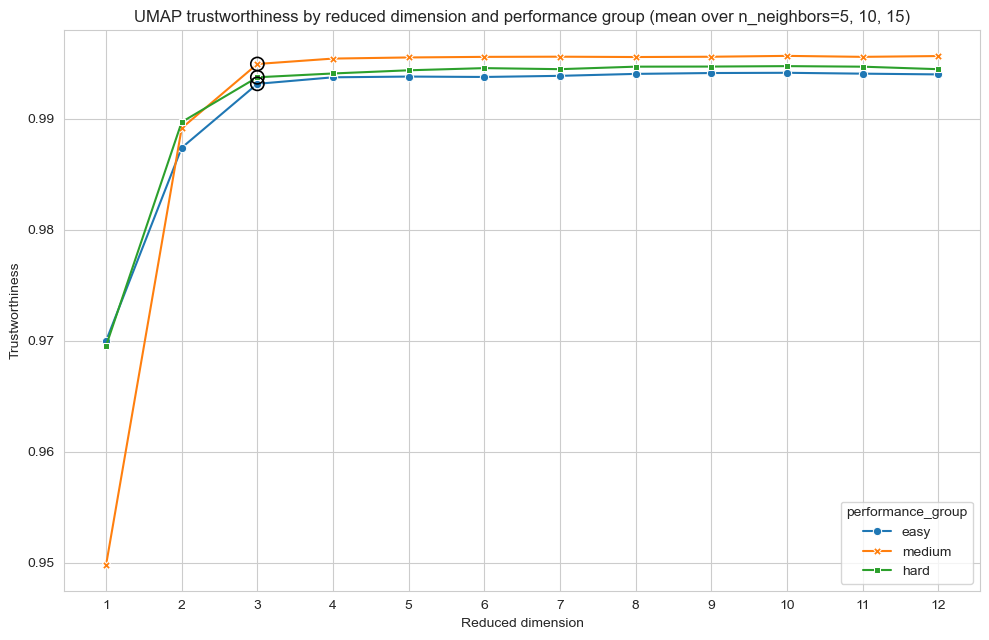

If the highlighted dimensions do not match your intended clustering setup, update CLUSTER_SPEC['umap_selected_n_components'] and rerun from the previous section.


,performance_group,n_components,trustworthiness_view,trustworthiness_n_neighbors,trustworthiness,selected_for_clustering
0,easy,1,nn_5,5,0.969701,False
1,easy,1,nn_10,10,0.970131,False
2,easy,1,nn_15,15,0.970109,False
3,easy,1,mean_5_10_15,<NA>,0.969980,False
4,easy,2,nn_5,5,0.988293,False
...,...,...,...,...,...,...
139,hard,11,mean_5_10_15,<NA>,0.994709,False
140,hard,12,nn_5,5,0.995753,False
141,hard,12,nn_10,10,0.994392,False
142,hard,12,nn_15,15,0.993305,False


In [5]:
def plot_trustworthiness_curves(
    trustworthiness_df: pd.DataFrame,
    *,
    plot_titles: dict[str, str],
    plot_paths: dict[str, Path],
) -> None:
    for trustworthiness_view, plot_title in plot_titles.items():
        plot_df = trustworthiness_df.loc[
            trustworthiness_df['trustworthiness_view'] == trustworthiness_view
        ].copy()
        if plot_df.empty:
            raise ValueError(f'Missing trustworthiness rows for view={trustworthiness_view!r}.')

        fig, ax = plt.subplots(figsize=(10, 6.5))
        sns.lineplot(
            data=plot_df,
            x='n_components',
            y='trustworthiness',
            hue='performance_group',
            style='performance_group',
            markers=True,
            dashes=False,
            ax=ax,
        )
        selected_points_df = plot_df.loc[plot_df['selected_for_clustering']].copy()
        if not selected_points_df.empty:
            ax.scatter(
                selected_points_df['n_components'],
                selected_points_df['trustworthiness'],
                s=90,
                facecolors='none',
                edgecolors='black',
                linewidths=1.2,
                zorder=5,
            )
        ax.set_title(plot_title)
        ax.set_xlabel('Reduced dimension')
        ax.set_ylabel('Trustworthiness')
        ax.set_xticks(sorted(plot_df['n_components'].unique().tolist()))
        plt.tight_layout()
        plt.savefig(plot_paths[trustworthiness_view], dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)


if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    trustworthiness_df = evaluate_umap_trustworthiness_by_group(
        analysis_df,
        cluster_spec=CLUSTER_SPEC_RESOLVED,
        performance_group_col=PERFORMANCE_GROUP_COL,
        effect_cols=effect_cols,
    )
    plot_trustworthiness_curves(
        trustworthiness_df,
        plot_titles=TRUSTWORTHINESS_PLOT_TITLES,
        plot_paths=UMAP_TRUSTWORTHINESS_PLOT_PATHS,
    )
    print(
        "If the highlighted dimensions do not match your intended clustering setup, "
        "update CLUSTER_SPEC['umap_selected_n_components'] and rerun from the previous section."
    )
else:
    trustworthiness_df = pd.DataFrame(columns=TRUSTWORTHINESS_COLUMNS)
    print("Skipped reduced-space trustworthiness evaluation because CLUSTER_SPEC['evaluate_umap_latent_space']=False.")

display(trustworthiness_df)


## Cluster Within Performance Groups
**Purpose:** Cluster feature-effect vectors separately inside each performance group and keep every candidate run available for downstream export and inspection.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `effect_cols`.<br>
**Outputs:** Candidate cluster assignments, scored clustering runs, and a best-run summary driven only by DBCV ranking metadata.<br>
**How to Verify:** Confirm that each performance group has scored cluster runs and that `selected_for_group` marks exactly one best-ranked candidate per group.


In [6]:
clustering_results = run_step2_clustering(
    analysis_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    performance_group_col=PERFORMANCE_GROUP_COL,
    row_id_col='row_id',
    effect_cols=effect_cols,
)

clustered_df = clustering_results['clustered_df']
cluster_scores_df = clustering_results['cluster_scores_df']
best_cluster_runs_df = cluster_scores_df.loc[cluster_scores_df['selected_for_group']].copy()

print(f'Cluster score rows: {len(cluster_scores_df)}')
print(f'Best-ranked regime runs: {len(best_cluster_runs_df)}')

display(cluster_scores_df)
display(best_cluster_runs_df)


/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

Cluster score rows: 12
Best-ranked regime runs: 3


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_effect_space,valid_for_selection,valid_for_raw_effect_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,6531,5,5,NaN,...,228,2029,0.310672,0.689328,0.322615,0.322615,-0.177902,True,True,True
3,3,easy,optics,umap,cluster_optics_umap,3,6531,5,5,0.05,...,421,2874,0.440055,0.559945,0.301110,0.301110,-0.052990,True,True,False
1,1,easy,optics,raw,cluster_optics_raw,13,6531,5,5,0.05,...,137,5511,0.843822,0.156178,0.069685,0.069685,0.069685,True,True,False
0,0,easy,hdbscan,raw,cluster_hdbscan_raw,13,6531,5,5,NaN,...,33,2095,0.320778,0.679222,-0.017078,-0.017078,-0.017078,True,True,False
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,6531,5,5,NaN,...,245,1883,0.288317,0.711683,0.352062,0.352062,-0.178283,True,True,True
11,11,hard,optics,umap,cluster_optics_umap,3,6531,5,5,0.05,...,415,2793,0.427653,0.572347,0.288606,0.288606,-0.052028,True,True,False
8,8,hard,hdbscan,raw,cluster_hdbscan_raw,13,6531,5,5,NaN,...,3,172,0.026336,0.973664,0.243199,0.243199,0.243199,True,True,False
9,9,hard,optics,raw,cluster_optics_raw,13,6531,5,5,0.05,...,141,5534,0.847343,0.152657,0.071784,0.071784,0.071784,True,True,False
6,6,medium,hdbscan,umap,cluster_hdbscan_umap,3,13060,5,5,NaN,...,445,4367,0.334380,0.665620,0.298580,0.298580,-0.165287,True,True,True
7,7,medium,optics,umap,cluster_optics_umap,3,13060,5,5,0.05,...,772,6075,0.465161,0.534839,0.286966,0.286966,-0.051309,True,True,False


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_effect_space,valid_for_selection,valid_for_raw_effect_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,6531,5,5,NaN,...,228,2029,0.310672,0.689328,0.322615,0.322615,-0.177902,True,True,True
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,6531,5,5,NaN,...,245,1883,0.288317,0.711683,0.352062,0.352062,-0.178283,True,True,True
6,6,medium,hdbscan,umap,cluster_hdbscan_umap,3,13060,5,5,NaN,...,445,4367,0.334380,0.665620,0.298580,0.298580,-0.165287,True,True,True


## Compare Clustering Outputs
**Purpose:** Show one panel per `(performance group, clustering algorithm)` combination for raw feature-effect space and, when enabled, reduced feature-effect spaces.<br>
**Inputs:** `cluster_scores_df`, `clustered_df`, resolved `CLUSTER_SPEC_RESOLVED`, and the shared visualization embedding stored in `clustered_df`.<br>
**Outputs:** Saved comparison grids plus compact summary tables for the raw and reduced clustering runs.<br>
**How to Verify:** Confirm that each visible panel uses the expected performance group and algorithm and that the DBCV and cluster-count annotations line up with `cluster_scores_df`.


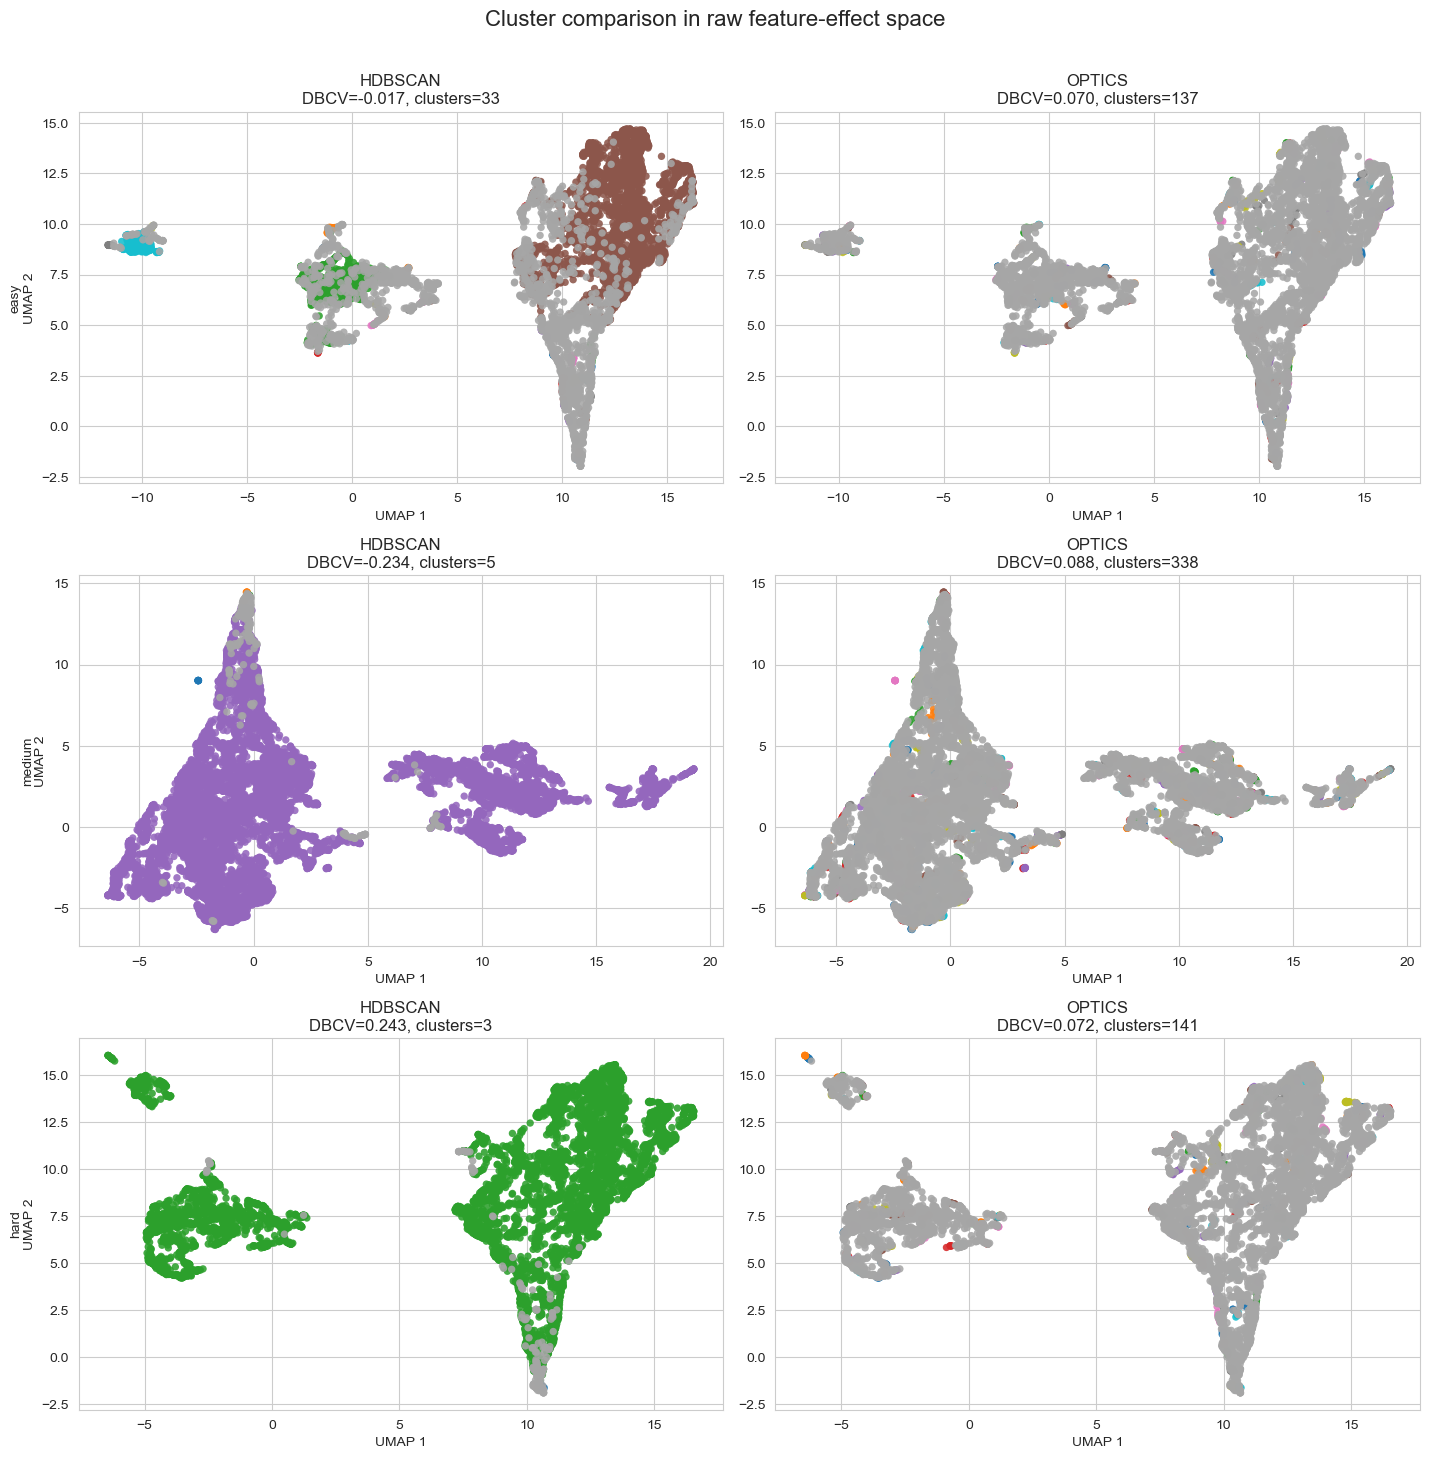

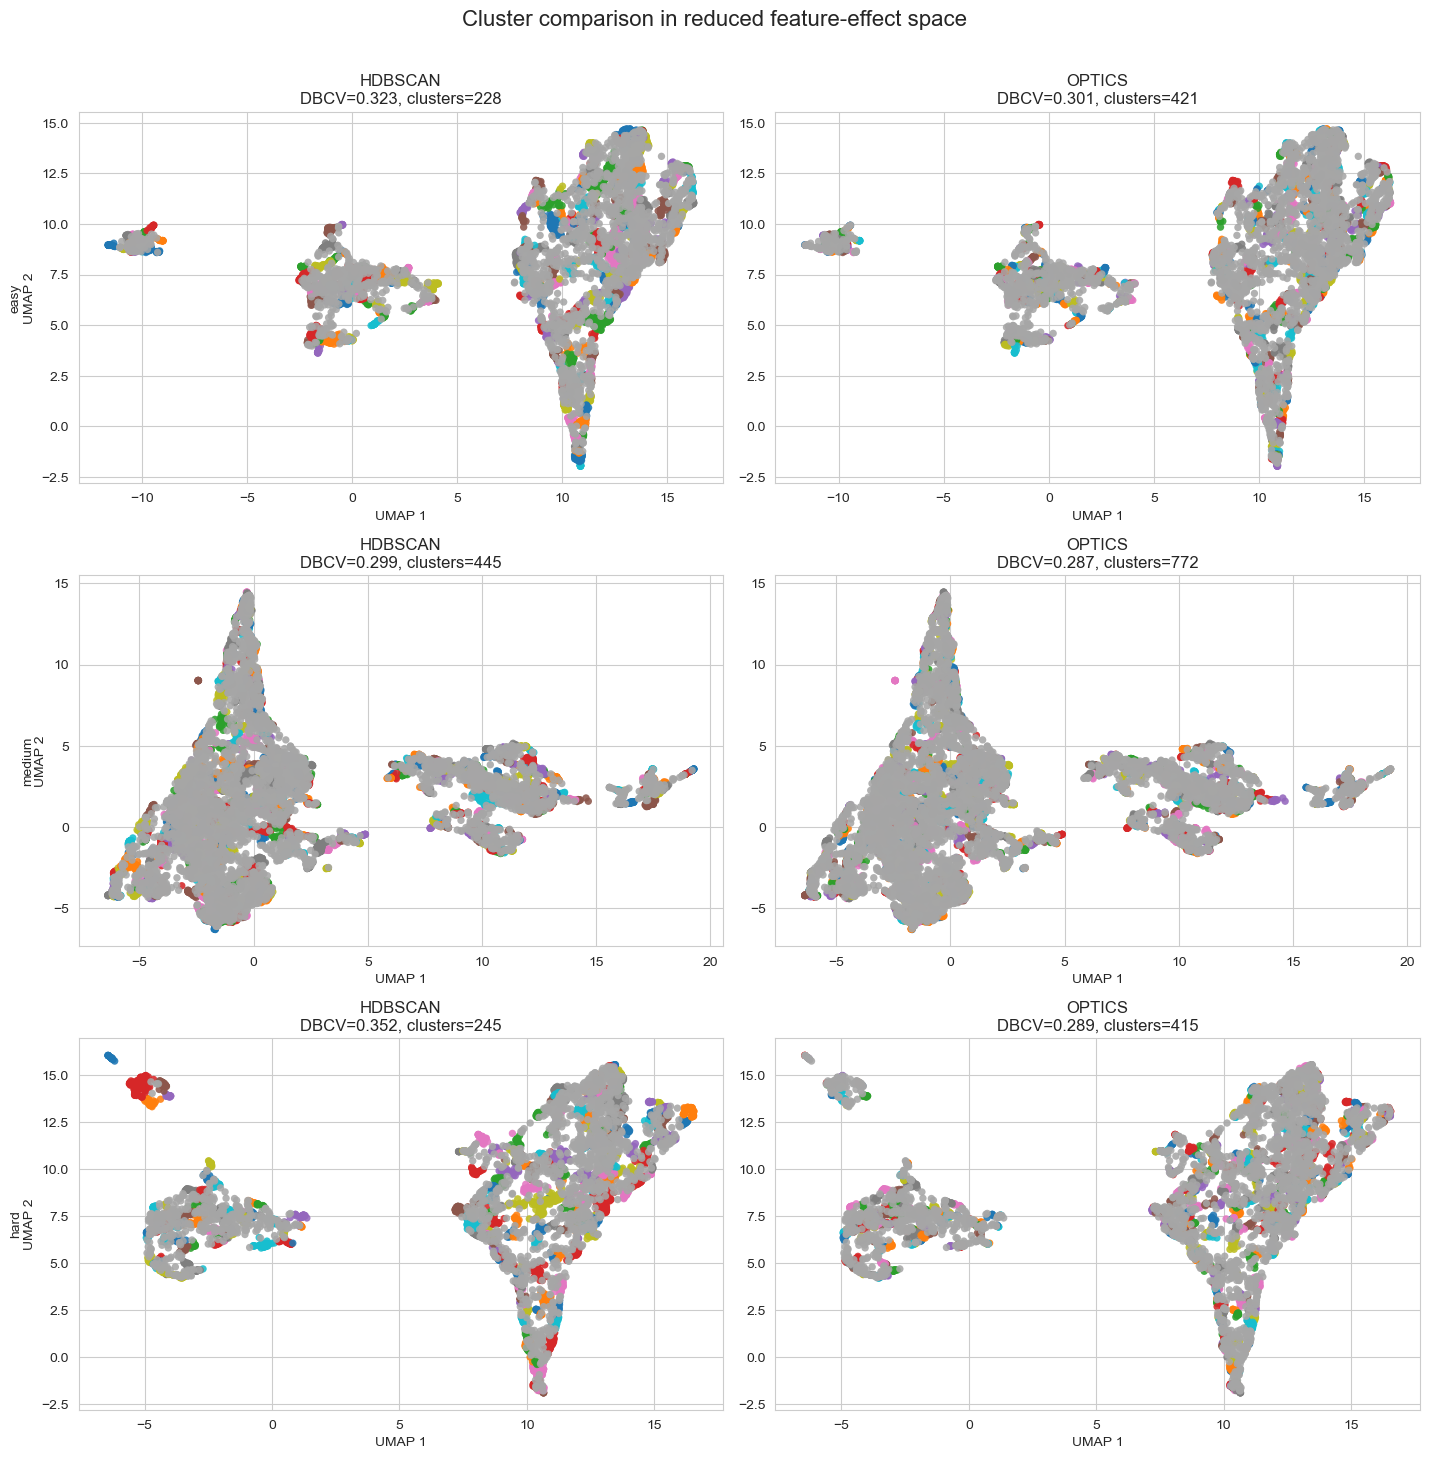

Raw-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_raw_effect_space,n_clusters,noise_fraction
0,easy,hdbscan,raw,-0.017078,33,0.320778
1,easy,optics,raw,0.069685,137,0.843822
2,hard,hdbscan,raw,0.243199,3,0.026336
3,hard,optics,raw,0.071784,141,0.847343
4,medium,hdbscan,raw,-0.233807,5,0.016769
5,medium,optics,raw,0.088221,338,0.808116


Reduced-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_raw_effect_space,n_clusters,noise_fraction
0,easy,hdbscan,umap,-0.177902,228,0.310672
1,easy,optics,umap,-0.052990,421,0.440055
2,hard,hdbscan,umap,-0.178283,245,0.288317
3,hard,optics,umap,-0.052028,415,0.427653
4,medium,hdbscan,umap,-0.165287,445,0.334380
5,medium,optics,umap,-0.051309,772,0.465161


In [7]:
def plot_cluster_comparison_grid(
    cluster_scores_subset: pd.DataFrame,
    *,
    plot_path: Path,
    cluster_space_label: str,
) -> pd.DataFrame:
    groups = CLUSTER_SPEC_RESOLVED['groups']
    algorithms = CLUSTER_SPEC_RESOLVED['algorithms']
    comparison_df = cluster_scores_subset.copy()
    fig, axes = plt.subplots(
        len(groups),
        len(algorithms),
        figsize=(7.2 * len(algorithms), 4.8 * len(groups)),
        squeeze=False,
    )

    for row_idx, performance_group in enumerate(groups):
        for col_idx, algorithm in enumerate(algorithms):
            ax = axes[row_idx][col_idx]
            selected_rows = comparison_df.loc[
                (comparison_df['performance_group'] == performance_group)
                & (comparison_df['algorithm'] == algorithm)
            ]
            if selected_rows.empty:
                ax.set_visible(False)
                continue

            comparison_row = selected_rows.iloc[0]
            group_df = clustered_df.loc[clustered_df[PERFORMANCE_GROUP_COL] == performance_group].copy()
            label_col = comparison_row['candidate_label_col']
            cluster_ids = [
                int(cluster_id)
                for cluster_id in group_df[label_col].dropna().astype(int).unique().tolist()
            ]
            ordered_cluster_ids = sorted(cluster_id for cluster_id in cluster_ids if cluster_id != -1)
            if -1 in cluster_ids:
                ordered_cluster_ids.append(-1)

            palette = sns.color_palette(
                'tab10',
                n_colors=max(len(ordered_cluster_ids) - (1 if -1 in ordered_cluster_ids else 0), 1),
            )
            color_lookup = {
                cluster_id: palette[idx % len(palette)]
                for idx, cluster_id in enumerate(
                    cluster_id for cluster_id in ordered_cluster_ids if cluster_id != -1
                )
            }
            if -1 in ordered_cluster_ids:
                color_lookup[-1] = (0.65, 0.65, 0.65)

            for cluster_id in ordered_cluster_ids:
                cluster_rows = group_df.loc[group_df[label_col].astype('Int64') == cluster_id]
                ax.scatter(
                    cluster_rows['viz_umap_x'],
                    cluster_rows['viz_umap_y'],
                    s=28,
                    alpha=0.88,
                    c=[color_lookup[cluster_id]],
                    edgecolors='none',
                )

            dbcv_cluster_space = comparison_row['dbcv_cluster_space']
            dbcv_cluster_label = f'{dbcv_cluster_space:.3f}' if pd.notna(dbcv_cluster_space) else 'NaN'
            panel_title = (
                f"{algorithm.upper()}\n"
                f"DBCV={dbcv_cluster_label}, clusters={int(comparison_row['n_clusters'])}"
            )
            ax.set_title(panel_title)
            ax.set_xlabel('UMAP 1')
            if col_idx == 0:
                ax.set_ylabel(f'{performance_group}\nUMAP 2')
            else:
                ax.set_ylabel('')

    fig.suptitle(f'Cluster comparison in {cluster_space_label}', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return comparison_df


raw_comparison_df = (
    cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'raw']
    .copy()
    .sort_values(['performance_group', 'algorithm'])
    .reset_index(drop=True)
)
plot_cluster_comparison_grid(
    raw_comparison_df,
    plot_path=RAW_ALGORITHM_GRID_PATH,
    cluster_space_label='raw feature-effect space',
)

if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    umap_comparison_df = (
        cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'umap']
        .copy()
        .sort_values(['performance_group', 'algorithm'])
        .reset_index(drop=True)
    )
    if umap_comparison_df.empty:
        raise ValueError(
            'Reduced-space clustering results are not available even though '
            "CLUSTER_SPEC['evaluate_umap_latent_space']=True."
        )
    plot_cluster_comparison_grid(
        umap_comparison_df,
        plot_path=UMAP_ALGORITHM_GRID_PATH,
        cluster_space_label='reduced feature-effect space',
    )
else:
    umap_comparison_df = pd.DataFrame(columns=cluster_scores_df.columns)
    print("Reduced-space comparison grid skipped because CLUSTER_SPEC['evaluate_umap_latent_space']=False.")

print('Raw-space clustering runs:')
display(
    raw_comparison_df[
        ['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_effect_space', 'n_clusters', 'noise_fraction']
    ]
)
print('Reduced-space clustering runs:')
display(
    umap_comparison_df[
        ['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_effect_space', 'n_clusters', 'noise_fraction']
    ]
)


## Assemble Candidate-Wide Cluster Exports
**Purpose:** Build lean downstream exports for every candidate cluster subset without duplicating the authoritative assignment table, and copy the run-level global feature-effect ranking into the cluster-spec export tree.<br>
**Inputs:** `clustered_df`, `cluster_scores_df`, resolved export paths, `raw_metric_col`, `effect_cols`, and `feature_effect_ranking_df`.<br>
**Outputs:** Candidate-wide `cluster_feature_effect_profiles_df`, `cluster_catalog_df`, one slim member file per exported cluster subset, and `feature_effect_global_ranking.csv` for downstream inspection ordering.<br>
**How to Verify:** Confirm that the catalog includes every `(performance group, algorithm, cluster space, cluster_id)` subset, including noise when present, and that the copied ranking table preserves the run-level global order.


In [8]:
cluster_export_outputs = write_cluster_exports(
    clustered_df,
    cluster_scores_df,
    export_layout=EXPORT_LAYOUT,
    performance_metric_col=raw_metric_col,
    performance_group_col=PERFORMANCE_GROUP_COL,
    effect_cols=effect_cols,
)

cluster_feature_effect_profiles_df = cluster_export_outputs['cluster_feature_effect_profiles_df']
cluster_catalog_df = cluster_export_outputs['cluster_catalog_df']
feature_effect_ranking_df.to_csv(FEATURE_EFFECT_GLOBAL_RANKING_PATH, index=False)

if cluster_export_outputs['cluster_feature_effect_profiles_path'] != CLUSTER_FEATURE_EFFECT_PROFILES_PATH:
    raise ValueError('Cluster feature-effect profile export path mismatch between notebook and export helper.')
if cluster_export_outputs['cluster_catalog_path'] != CLUSTER_CATALOG_PATH:
    raise ValueError('Cluster catalog export path mismatch between notebook and export helper.')

print(f'Cluster profile rows: {len(cluster_feature_effect_profiles_df)}')
print(f'Cluster catalog rows: {len(cluster_catalog_df)}')
print(f'Copied global ranking rows: {len(feature_effect_ranking_df)}')

display(cluster_catalog_df.head())
display(cluster_feature_effect_profiles_df.head())
display(feature_effect_ranking_df.head())


Cluster profile rows: 3195
Cluster catalog rows: 3195
Copied global ranking rows: 13


,performance_group,algorithm,cluster_space,candidate_label_col,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,cluster_rank_by_size,unique_scene_step_count,unique_scene_count,members_relative_path
0,easy,hdbscan,raw,cluster_hdbscan_raw,25,cluster_25,False,3192,0.488746,1.0,1474,141,tables/cluster_members__group-easy__alg-hdbsca...
1,easy,hdbscan,raw,cluster_hdbscan_raw,32,cluster_32,False,738,0.113000,2.0,578,111,tables/cluster_members__group-easy__alg-hdbsca...
2,easy,hdbscan,raw,cluster_hdbscan_raw,19,cluster_19,False,220,0.033685,3.0,200,72,tables/cluster_members__group-easy__alg-hdbsca...
3,easy,hdbscan,raw,cluster_hdbscan_raw,31,cluster_31,False,36,0.005512,4.0,34,28,tables/cluster_members__group-easy__alg-hdbsca...
4,easy,hdbscan,raw,cluster_hdbscan_raw,5,cluster_5,False,18,0.002756,5.0,18,16,tables/cluster_members__group-easy__alg-hdbsca...


,performance_group,algorithm,cluster_space,candidate_label_col,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,effect__max_speed,...,effect__has_collision,effect__min_neighbor_distance,effect__scene_num_agents,effect__scene_num_VEHICLE,effect__scene_bbox_area,effect__scene_bbox_width,effect__scene_bbox_height,effect__scene_spatial_density,effect__scene_density_VEHICLE,cluster_rank_by_size
0,easy,hdbscan,raw,cluster_hdbscan_raw,25,cluster_25,False,3192,0.488746,-0.978983,...,0.060025,0.044539,0.099502,0.046788,-0.005439,-0.001686,-0.037846,-0.601218,0.677014,1
1,easy,hdbscan,raw,cluster_hdbscan_raw,32,cluster_32,False,738,0.113000,-1.419601,...,0.057812,0.042749,0.099893,0.040542,0.002796,-0.000289,-0.042954,-0.604790,0.678700,2
2,easy,hdbscan,raw,cluster_hdbscan_raw,19,cluster_19,False,220,0.033685,-1.290782,...,0.060382,0.047910,0.103638,0.039606,-0.003143,-0.000809,-0.040034,-0.601423,0.680513,3
3,easy,hdbscan,raw,cluster_hdbscan_raw,31,cluster_31,False,36,0.005512,-1.463419,...,0.054529,0.027323,-0.040418,0.110276,0.066022,-0.034832,-0.062149,-0.556956,0.670845,4
4,easy,hdbscan,raw,cluster_hdbscan_raw,5,cluster_5,False,18,0.002756,-0.989173,...,0.061467,0.047513,0.096863,0.044623,0.006883,-0.003996,-0.047573,-0.598651,0.681189,5


,feature,global_rank,p_value,neg_log10_p_value,significant_0_05,importance_metric,importance_value,importance_ascending
0,max_speed,1,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
1,mean_acceleration,2,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
2,path_efficiency,3,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
3,std_speed,4,1.110223e-16,15.954590,True,p_value,1.110223e-16,True
4,min_neighbor_distance,5,1.276868e-12,11.893854,True,p_value,1.276868e-12,True


## Export Regime Artifacts
**Purpose:** Persist the assembled regime table, clustering outputs, candidate-wide export artifacts, and the copied global feature-effect ranking for downstream interpretation.<br>
**Inputs:** The completed notebook dataframes, export-helper outputs, and the plot paths accumulated in earlier sections.<br>
**Outputs:** CSV exports, saved plot files, and a manifest table that records only the main clustering artifacts required by downstream notebooks.<br>
**How to Verify:** Check that every printed output path exists under the run-specific results directory and that the manifest records the neutral feature-effect artifact names.


In [9]:
analysis_df.to_csv(REGIME_ANALYSIS_PATH, index=False)
group_summary_df.to_csv(PERFORMANCE_GROUP_SUMMARY_PATH, index=False)
trustworthiness_df.to_csv(UMAP_TRUSTWORTHINESS_PATH, index=False)
cluster_scores_df.to_csv(CLUSTER_SCORES_PATH, index=False)
# `cluster_assignments.csv` stays authoritative because it keeps the full joined table, feature effects,
# visualization embedding, and every candidate label column in one place.
clustered_df.to_csv(CLUSTER_ASSIGNMENTS_PATH, index=False)

current_artifact_records = [
    {
        'artifact_kind': 'table',
        'artifact_type': 'regime_analysis',
        'relative_path': str(REGIME_ANALYSIS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(REGIME_ANALYSIS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'performance_group_summary',
        'relative_path': str(PERFORMANCE_GROUP_SUMMARY_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(PERFORMANCE_GROUP_SUMMARY_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'umap_trustworthiness',
        'relative_path': str(UMAP_TRUSTWORTHINESS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(UMAP_TRUSTWORTHINESS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'cluster_scores',
        'relative_path': str(CLUSTER_SCORES_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(CLUSTER_SCORES_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'cluster_assignments',
        'relative_path': str(CLUSTER_ASSIGNMENTS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(CLUSTER_ASSIGNMENTS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'feature_effect_global_ranking',
        'relative_path': str(FEATURE_EFFECT_GLOBAL_RANKING_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(FEATURE_EFFECT_GLOBAL_RANKING_PATH.resolve()),
    },
    {
        'artifact_kind': 'plot',
        'artifact_type': 'raw_algorithm_comparison_grid',
        'relative_path': str(RAW_ALGORITHM_GRID_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(RAW_ALGORITHM_GRID_PATH.resolve()),
    },
]
if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    current_artifact_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'umap_algorithm_comparison_grid',
            'relative_path': str(UMAP_ALGORITHM_GRID_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(UMAP_ALGORITHM_GRID_PATH.resolve()),
        }
    )
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    current_artifact_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'umap_trustworthiness_curve',
            'trustworthiness_view': trustworthiness_view,
            'relative_path': str(plot_path.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(plot_path.resolve()),
        }
    )
current_artifact_records.extend(cluster_export_outputs['artifact_records'])

manifest_data = load_or_initialize_feature_effect_regime_manifest(
    EXPORT_MANIFEST_PATH,
    run_context={
        'model_id': MODEL_ID,
        'run_name': RUN_NAME,
        'target_col': target_col,
        'target_mode': target_mode,
        'eval_csv_name': EVAL_CSV_NAME,
        'run_manifest_path': str(run_ctx.manifest_path),
        'prepared_data_path': str(PREPARED_DATA_PATH),
        'feature_effects_path': str(FEATURE_EFFECTS_PATH),
        'feature_effect_importance_path': str(FEATURE_EFFECT_IMPORTANCE_PATH),
        'joined_metrics_path': str(JOINED_METRICS_PATH),
    },
    data_context={
        'target_col': target_col,
        'eval_csv_name': EVAL_CSV_NAME,
        'lower_is_better': LOWER_IS_BETTER,
        'performance_group_col': PERFORMANCE_GROUP_COL,
        'data_context_slug': EXPORT_CONTEXT['data_context_slug'],
    },
    cluster_spec={
        'raw': CLUSTER_SPEC,
        'resolved': CLUSTER_SPEC_RESOLVED,
        'readable_slug': EXPORT_LAYOUT['cluster_spec_readable_slug'],
        'hash': EXPORT_LAYOUT['cluster_spec_hash'],
        'dirname': EXPORT_LAYOUT['cluster_spec_dirname'],
    },
)
manifest_data = merge_feature_effect_regime_artifact_records(
    manifest_data,
    artifact_records=current_artifact_records,
)
EXPORT_MANIFEST_PATH.write_text(json.dumps(manifest_data, indent=2))
artifact_manifest_df = pd.DataFrame(manifest_data['artifacts'])

print('Saved artifacts:')
print(f'- Run manifest:                 {run_ctx.manifest_path}')
print(f'- Prepared data export:         {PREPARED_DATA_PATH}')
print(f'- Feature-effect export:        {FEATURE_EFFECTS_PATH}')
print(f'- Feature-effect importance:    {FEATURE_EFFECT_IMPORTANCE_PATH}')
print(f'- Joined metrics export:        {JOINED_METRICS_PATH}')
print(f'- Cluster-spec export root:     {EXPORT_LAYOUT["cluster_spec_root"]}')
print(f'- Export manifest:              {EXPORT_MANIFEST_PATH}')
print(f'- Regime analysis table:        {REGIME_ANALYSIS_PATH}')
print(f'- Performance group summary:    {PERFORMANCE_GROUP_SUMMARY_PATH}')
print(f'- UMAP trustworthiness:         {UMAP_TRUSTWORTHINESS_PATH}')
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    print(f'- Trustworthiness curve ({trustworthiness_view}): {plot_path}')
print(f'- Cluster scores:               {CLUSTER_SCORES_PATH}')
print(f'- Cluster assignments:          {CLUSTER_ASSIGNMENTS_PATH}')
print(f'- Cluster feature-effect profiles: {CLUSTER_FEATURE_EFFECT_PROFILES_PATH}')
print(f'- Cluster catalog:              {CLUSTER_CATALOG_PATH}')
print(f'- Copied global ranking:        {FEATURE_EFFECT_GLOBAL_RANKING_PATH}')
print(f'- Raw comparison grid:          {RAW_ALGORITHM_GRID_PATH}')
if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    print(f'- Reduced comparison grid:      {UMAP_ALGORITHM_GRID_PATH}')
else:
    print("- Reduced comparison grid:      skipped (CLUSTER_SPEC['evaluate_umap_latent_space']=False)")
print(f'- Tables directory:             {TABLES_DIR}')
print(f'- Plot directory:               {PLOTS_DIR}')

display(artifact_manifest_df)


Saved artifacts:
- Run manifest:                 /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/tables/run_manifest_ml_ade_log.json
- Prepared data export:         ../../results/interpretable_model/prepared_data/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/prepared_data_ml_ade.csv
- Feature-effect export:        /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/tables/feature_effects_ml_ade_log.csv
- Feature-effect importance:    /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/tables/feature_effect_importance_ml_ade_log.csv
- Joined metrics export:        ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_trainval_debug_tpp-12_Apr_2026_22_51_36/eval_epoch_5.csv
- Cluster-spec export root:     /Users/simond

,artifact_kind,artifact_type,relative_path,absolute_path,trustworthiness_view,performance_group,algorithm,cluster_space,cluster_id,is_noise,cluster_size
0,plot,raw_algorithm_comparison_grid,plots/algorithm_comparison_grid__space-raw.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,plot,umap_algorithm_comparison_grid,plots/algorithm_comparison_grid__space-umap.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,plot,umap_trustworthiness_curve,plots/umap_trustworthiness_curve__view-mean_5_...,/Users/simondrauz/Lokale Dokumente/Repositorie...,mean_5_10_15,NaN,NaN,NaN,NaN,NaN,NaN
3,plot,umap_trustworthiness_curve,plots/umap_trustworthiness_curve__view-nn_10.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,nn_10,NaN,NaN,NaN,NaN,NaN,NaN
4,plot,umap_trustworthiness_curve,plots/umap_trustworthiness_curve__view-nn_15.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,nn_15,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3204,table,cluster_scores,tables/cluster_scores.csv,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3205,table,feature_effect_global_ranking,tables/feature_effect_global_ranking.csv,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3206,table,performance_group_summary,tables/performance_group_summary.csv,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3207,table,regime_analysis,tables/regime_analysis.csv,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
